<a href="https://colab.research.google.com/github/inteligencia-artificial-e-afins/sistema-de-recomendacao-bom-e-novo/blob/main/EDA_MovieLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q -o ml-latest-small.zip
!ls -lh ml-latest-small

total 3.2M
-rw-r--r-- 1 root root 194K Sep 26  2018 links.csv
-rw-r--r-- 1 root root 483K Sep 26  2018 movies.csv
-rw-r--r-- 1 root root 2.4M Sep 26  2018 ratings.csv
-rw-r--r-- 1 root root 8.2K Sep 26  2018 README.txt
-rw-r--r-- 1 root root 116K Sep 26  2018 tags.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
BASE = "ml-latest-small/"

ratings = pd.read_csv(BASE + "ratings.csv")
movies  = pd.read_csv(BASE + "movies.csv")
tags    = pd.read_csv(BASE + "tags.csv")
links   = pd.read_csv(BASE + "links.csv")

print("Arquivos carregados com sucesso!")

Arquivos carregados com sucesso!


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [8]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## Tamanho e "saúde" dos dados:

In [9]:
for nome, df in [("ratings", ratings), ("movies", movies), ("tags", tags), ("links", links)]:
    print(f"\n{'='*40}")
    print(f"{nome.upper()}")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    print(f"\nValores nulos por coluna:\n{df.isna().sum()}")
    print(f"\nLinhas duplicadas: {df.duplicated().sum()}")


RATINGS
Linhas: 100836 | Colunas: 4

Valores nulos por coluna:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Linhas duplicadas: 0

MOVIES
Linhas: 9742 | Colunas: 3

Valores nulos por coluna:
movieId    0
title      0
genres     0
dtype: int64

Linhas duplicadas: 0

TAGS
Linhas: 3683 | Colunas: 4

Valores nulos por coluna:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Linhas duplicadas: 0

LINKS
Linhas: 9742 | Colunas: 3

Valores nulos por coluna:
movieId    0
imdbId     0
tmdbId     8
dtype: int64

Linhas duplicadas: 0


In [10]:
ratings["rating"].describe()

,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


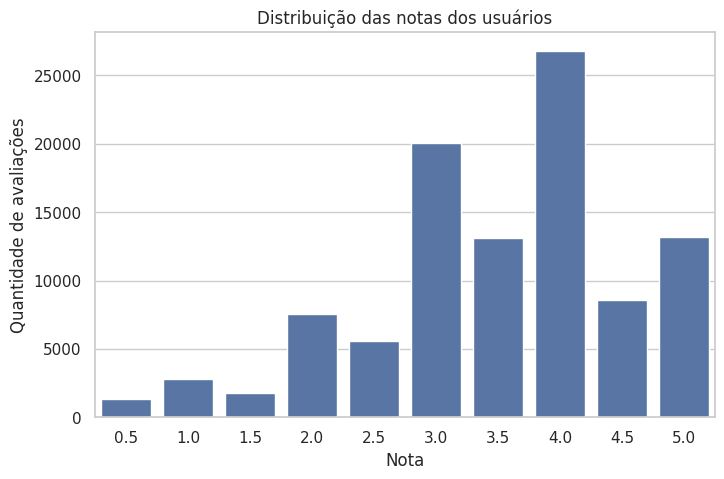

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="rating", data=ratings)
plt.title("Distribuição das notas dos usuários")
plt.xlabel("Nota")
plt.ylabel("Quantidade de avaliações")
plt.show()

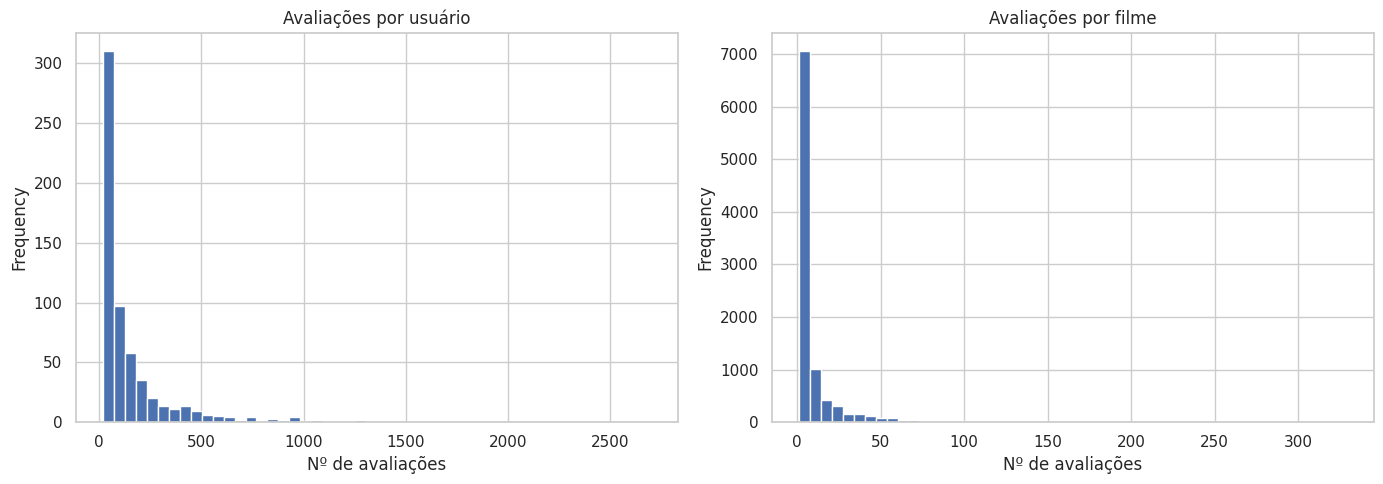

Usuário que mais avaliou: 2698 avaliações
Filme mais avaliado: 329 avaliações


In [12]:
avaliacoes_por_usuario = ratings.groupby("userId").size()
avaliacoes_por_filme = ratings.groupby("movieId").size()

fig, ax = plt.subplots(1, 2, figsize=(14,5))

avaliacoes_por_usuario.plot(kind="hist", bins=50, ax=ax[0])
ax[0].set_title("Avaliações por usuário")
ax[0].set_xlabel("Nº de avaliações")

avaliacoes_por_filme.plot(kind="hist", bins=50, ax=ax[1])
ax[1].set_title("Avaliações por filme")
ax[1].set_xlabel("Nº de avaliações")

plt.tight_layout()
plt.show()

print(f"Usuário que mais avaliou: {avaliacoes_por_usuario.max()} avaliações")
print(f"Filme mais avaliado: {avaliacoes_por_filme.max()} avaliações")

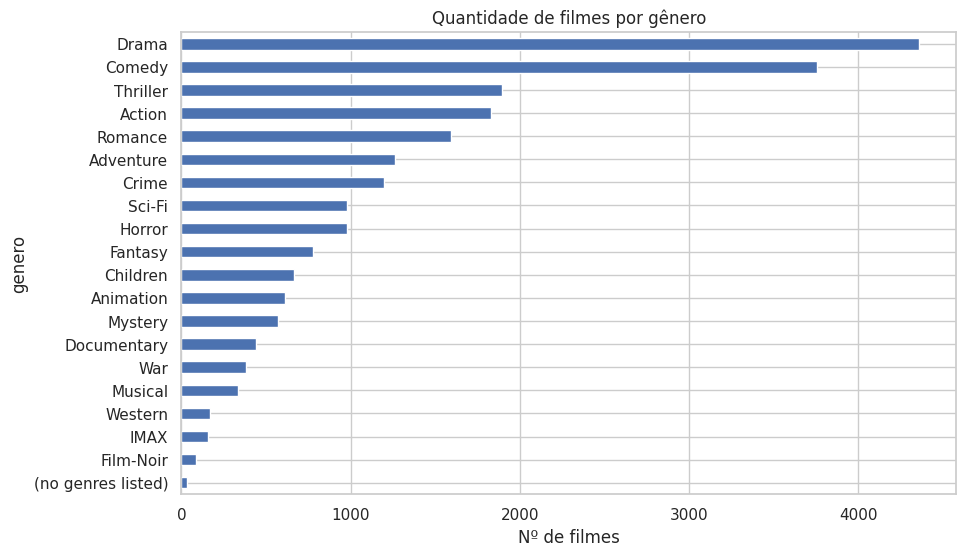

In [13]:
movies_generos = movies.assign(genero=movies["genres"].str.split("|")).explode("genero")

contagem_generos = movies_generos["genero"].value_counts()

plt.figure(figsize=(10,6))
contagem_generos.plot(kind="barh")
plt.title("Quantidade de filmes por gênero")
plt.xlabel("Nº de filmes")
plt.gca().invert_yaxis()
plt.show()

## Conclusões do EDA

- O dataset **ml-latest-small** contém 100.836 avaliações, aplicadas a 9.742 filmes.
- Não há valores nulos relevantes: apenas 8 registros em `links` (tmdbId) ficaram sem preenchimento, o que não afeta a análise.
- Não foram encontradas linhas duplicadas em nenhuma das quatro tabelas.
- As notas variam de 0.5 a 5.0, com média de 3.50 e mediana de 3.5 — indicando uma tendência dos usuários a avaliar os filmes positivamente, mais do que negativamente.
- A distribuição das notas mostra concentração nos valores 3.0, 4.0 e 5.0, reforçando esse viés positivo.
- Tanto as avaliações por usuário quanto por filme seguem uma distribuição de **cauda longa**: a maioria dos usuários e filmes tem poucas avaliações, enquanto poucos concentram um volume muito alto (o usuário mais ativo fez 2.698 avaliações, e o filme mais avaliado recebeu 329 avaliações).
- Em relação aos gêneros, **Drama** e **Comedy** são disparadamente os mais frequentes entre os filmes do catálogo, seguidos por Thriller e Action. Gêneros como Film-Noir, IMAX e "(no genres listed)" aparecem com pouquíssima frequência.

### Próximos passos possíveis
Esse EDA serve de base para etapas futuras, como a construção de um sistema de recomendação (filtragem colaborativa, por exemplo), já que os dados mostram esparsidade típica desse tipo de problema: poucos usuários avaliaram a maioria dos filmes.